In [1]:
#hamra target ye hai ki hame zada fail sample pakdne hai iske liye smote kiya taki synethic fail sample ban sake unko balance karke train kr sake 

#dusra tarika hota threshold tuning ki mano 0.5 threshold sigmoid function se classify hota uski jagah threshold 0.3 rakhna 


# tesra tarika hota hai ki class_weight balanced model ko samajna hota ki fail miss krna zada costly hai ye hyperparameter hota hai jise aap model ke training ke time set kar sakte ho



""" Normal training mein:
PASS galat → penalty = 1
FAIL galat → penalty = 1
(Same penalty — model PASS ko zyada importance deta hai
 kyunki zyada samples hain!)

class_weight='balanced' ke saath:
PASS galat → penalty = 1
FAIL galat → penalty = 14
(FAIL miss karna 14x zyada costly!)

Penalty kahan se aayi?
1463/104 ≈ 14
Matlab FAIL samples 14 guna kam hain
toh unki penalty 14 guna zyada! """

" Normal training mein:\nPASS galat → penalty = 1\nFAIL galat → penalty = 1\n(Same penalty — model PASS ko zyada importance deta hai\n kyunki zyada samples hain!)\n\nclass_weight='balanced' ke saath:\nPASS galat → penalty = 1\nFAIL galat → penalty = 14\n(FAIL miss karna 14x zyada costly!)\n\nPenalty kahan se aayi?\n1463/104 ≈ 14\nMatlab FAIL samples 14 guna kam hain\ntoh unki penalty 14 guna zyada! "

In [2]:
#import relevant libraries and train testing dataset

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,roc_auc_score,roc_curve)


import warnings 
warnings.filterwarnings('ignore')

X_train=np.load('../data/processed/X_train.npy')
y_train=np.load('../data/processed/y_train.npy')
X_test=np.load('../data/processed/X_test.npy')
y_test=np.load('../data/processed/y_test.npy')


print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2340, 195)
(2340,)
(314, 195)
(314,)


In [4]:
#logistic regression 
lr=LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000,C=1.0)

lr.fit(X_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [5]:
#making predictions of lr based on probabilites 
y_pred=lr.predict(X_test)
y_pred_prob=lr.predict_proba(X_test)[:,1]#ye fail hone ki prob hai dhyan rakhio 

In [6]:
y_pred_prob.shape

(314,)

In [7]:
y_pred_prob[:10]

array([1.14746096e-02, 1.01343824e-01, 7.76530804e-03, 4.22153993e-05,
       5.74069619e-03, 2.21935329e-03, 9.77211801e-01, 2.81029870e-02,
       8.50694101e-01, 9.19919946e-03])

              precision    recall  f1-score   support

     PASS(0)       0.94      0.89      0.91       293
     FAIL(1)       0.13      0.24      0.17        21

    accuracy                           0.84       314
   macro avg       0.54      0.56      0.54       314
weighted avg       0.89      0.84      0.86       314



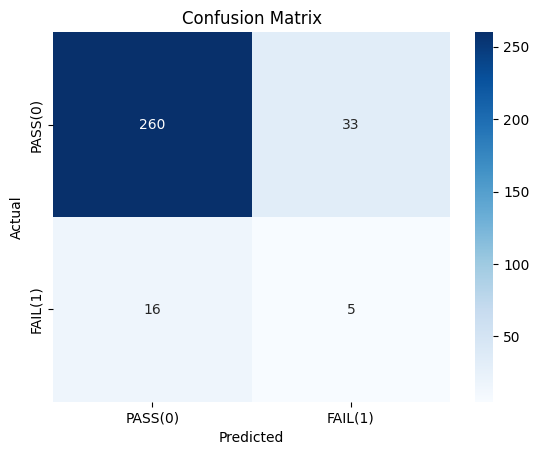

ROC-AUC: 0.6641


In [8]:
print(classification_report(y_test, y_pred, 
      target_names=["PASS(0)", "FAIL(1)"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["PASS(0)", "FAIL(1)"],
            yticklabels=["PASS(0)", "FAIL(1)"])
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

In [9]:
#260 is total predicted pass mei se kitni actual pass
#33 predicted fail mei se kitni actual pass
#precision 260/260+16
#5/5+33
#recall 
#yani kitni actual pass ko model ne pass kiya 
#260/260+33
#5/16+5



In [10]:
#precision and recall with example 
""" Socho hospital mein 314 patients aaye:

293 actually Beemar hain (FAIL)
21 actually Theek hain (PASS)

Doctor (model) ne predict kiya — kya result aaya? """


#precision 
"Jab maine PASS bola — kitni baar sach tha?"

""" Example:
Model ne 50 logon ko PASS bola
Unme se sirf 6-7 sach mein PASS the
Baaki sab beemar the!

Precision(PASS) = 0.13
Matlab: 13% cases mein sahi tha
87% cases mein galat tha! ❌ """



#recall
""" "Jinhe actually PASS hona chahiye tha
 unme se kitne pakde?"

Example:
21 actually PASS patients the
Model ne unme se sirf 5 pakde

Recall(PASS) = 5/21 = 0.24
Matlab: 24% actual PASS pakde
76% PASS miss kar diye! ❌ """


' "Jinhe actually PASS hona chahiye tha\n unme se kitne pakde?"\n\nExample:\n21 actually PASS patients the\nModel ne unme se sirf 5 pakde\n\nRecall(PASS) = 5/21 = 0.24\nMatlab: 24% actual PASS pakde\n76% PASS miss kar diye! ❌ '

In [11]:
#roc ko samnjte hai sabse pehle to hamne probability fail hone ki liye hai kyoki hamra target fail ko pakdna hai to hamne fail hone ki probability nikali hai aur uske basis pe roc curve banayenge

#[:,0] pass hone ki probability hoti hai aur [:,1] fail hone ki probability hoti hai


#roc curve ko samjte hai 

""" Threshold kam karo:
→ Zyada FAIL pakdoge    ✅ (Recall badhega)
→ Zyada False Alarms    ❌ (FPR badhega)

Threshold badhao:
→ Kam False Alarms      ✅ (FPR ghategaa)
→ Zyada FAIL miss hoge  ❌ (Recall ghategaa) """


#roc curve haar possible threshold pr x axis pr false postive rate y axis pr true positive rate plot karta hai

#true positive rate =recall hota hai 
#true postive rate=tp/(tp+fn)

""" Threshold 0.9 → Point (0.02, 0.30)
Threshold 0.7 → Point (0.08, 0.55)
Threshold 0.5 → Point (0.15, 0.75)
Threshold 0.3 → Point (0.30, 0.88)
Threshold 0.1 → Point (0.70, 0.95)

Sab points milao → ROC Curve! """

' Threshold 0.9 → Point (0.02, 0.30)\nThreshold 0.7 → Point (0.08, 0.55)\nThreshold 0.5 → Point (0.15, 0.75)\nThreshold 0.3 → Point (0.30, 0.88)\nThreshold 0.1 → Point (0.70, 0.95)\n\nSab points milao → ROC Curve! '

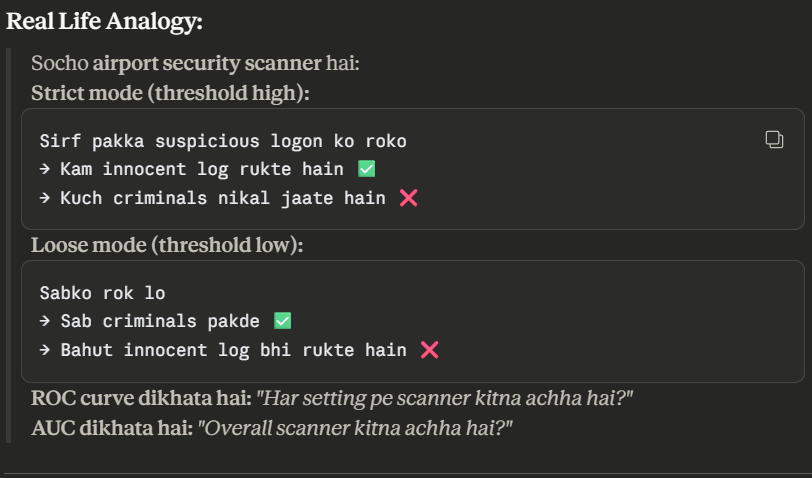

In [12]:
""" ROC-AUC = 0.66

Matlab:
Agar ek random FAIL sample aur
ek random PASS sample lo —

Model 66% cases mein
FAIL ko PASS se upar rank karega

Perfect hota toh 100%!
Random hota toh 50%!
Hamara 66% — theek hai baseline ke liye """

' ROC-AUC = 0.66\n\nMatlab:\nAgar ek random FAIL sample aur\nek random PASS sample lo —\n\nModel 66% cases mein\nFAIL ko PASS se upar rank karega\n\nPerfect hota toh 100%!\nRandom hota toh 50%!\nHamara 66% — theek hai baseline ke liye '

In [13]:
#auc calulation krte hai 

""" 
Actual FAIL chips:
Chip F1 → 0.72  (72% FAIL probability)
Chip F2 → 0.45  (45% FAIL probability)
Chip F3 → 0.81  (81% FAIL probability)
Chip F4 → 0.38  (38% FAIL probability)
Chip F5 → 0.60  (60% FAIL probability)

Actual PASS chips:
Chip P1 → 0.55  (55% FAIL probability)
Chip P2 → 0.23  (23% FAIL probability)
Chip P3 → 0.67  (67% FAIL probability)
Chip P4 → 0.31  (31% FAIL probability)
Chip P5 → 0.48  (48% FAIL probability) """



#harr fail chip pass se check hogi 5*5=25 pairs to check if fail ki probability pass se zyada hai ya nahi

""" F1(0.72) vs P1(0.55) → 0.72 > 0.55 ✅ FAIL upar
F1(0.72) vs P2(0.23) → 0.72 > 0.23 ✅ FAIL upar
F1(0.72) vs P3(0.67) → 0.72 > 0.67 ✅ FAIL upar
F1(0.72) vs P4(0.31) → 0.72 > 0.31 ✅ FAIL upar
F1(0.72) vs P5(0.48) → 0.72 > 0.48 ✅ FAIL upar

F2(0.45) vs P1(0.55) → 0.45 < 0.55 ❌ PASS upar
F2(0.45) vs P2(0.23) → 0.45 > 0.23 ✅ FAIL upar
F2(0.45) vs P3(0.67) → 0.45 < 0.67 ❌ PASS upar
F2(0.45) vs P4(0.31) → 0.45 > 0.31 ✅ FAIL upar
F2(0.45) vs P5(0.48) → 0.45 < 0.48 ❌ PASS upar

F3(0.81) vs P1(0.55) → 0.81 > 0.55 ✅ FAIL upar
F3(0.81) vs P2(0.23) → 0.81 > 0.23 ✅ FAIL upar
F3(0.81) vs P3(0.67) → 0.81 > 0.67 ✅ FAIL upar
F3(0.81) vs P4(0.31) → 0.81 > 0.31 ✅ FAIL upar
F3(0.81) vs P5(0.48) → 0.81 > 0.48 ✅ FAIL upar

F4(0.38) vs P1(0.55) → 0.38 < 0.55 ❌ PASS upar
F4(0.38) vs P2(0.23) → 0.38 > 0.23 ✅ FAIL upar
F4(0.38) vs P3(0.67) → 0.38 < 0.67 ❌ PASS upar
F4(0.38) vs P4(0.31) → 0.38 > 0.31 ✅ FAIL upar
F4(0.38) vs P5(0.48) → 0.38 < 0.48 ❌ PASS upar

F5(0.60) vs P1(0.55) → 0.60 > 0.55 ✅ FAIL upar
F5(0.60) vs P2(0.23) → 0.60 > 0.23 ✅ FAIL upar
F5(0.60) vs P3(0.67) → 0.60 < 0.67 ❌ PASS upar
F5(0.60) vs P4(0.31) → 0.60 > 0.31 ✅ FAIL upar
F5(0.60) vs P5(0.48) → 0.60 > 0.48 ✅ FAIL upar """

""" 
✅ FAIL upar = 18 pairs
❌ PASS upar =  7 pairs
Total        = 25 pairs

AUC = 18/25 = 0.72
 """



#AUC = 0.72 matlab:

""" "Agar randomly ek FAIL chip
 aur ek PASS chip uthao —

 72% chance hai ki model
 FAIL chip ko zyada suspicious
 rank karega PASS chip se!"

Perfect hota toh:
Sab 25 pairs mein FAIL upar → AUC = 1.0

Random hota toh:
~12-13 pairs mein FAIL upar → AUC = 0.5 """



""" "66% FAIL vs PASS pairs mein
    FAIL ko correctly zyada
    suspicious rank karta hai"
    → Yeh sahi hai! """


#mtlb maie do chip uthayi ek pass thi ek fail dono ki probability dekhi to fail wale ki probability pass wale se 66% zada hogi?


""" 
2 chips uthao:
1 actual FAIL chip
1 actual PASS chip

Model dono ko probability dega:
FAIL chip  → koi probability
PASS chip  → koi probability

66% chance hai ki:
FAIL chip ki probability >
PASS chip ki probability

34% chance hai ki:
PASS chip ki probability >
FAIL chip ki probability ← Model confuse hua """

' \n2 chips uthao:\n1 actual FAIL chip\n1 actual PASS chip\n\nModel dono ko probability dega:\nFAIL chip  → koi probability\nPASS chip  → koi probability\n\n66% chance hai ki:\nFAIL chip ki probability >\nPASS chip ki probability\n\n34% chance hai ki:\nPASS chip ki probability >\nFAIL chip ki probability ← Model confuse hua '

<h1>very very important </h1>

<p>66% ka mtlb ye nhi ki fail chips zada ye mtlb hai ki jitni bhi fail ho unme se 66% chips ki probabilty pass wale se zada hogi </p>

<!-- ROC-AUC = 0.66

Matlab:
Agar ek random FAIL sample aur
ek random PASS sample lo —

Model 66% cases mein
FAIL ko PASS se upar rank karega

Perfect hota toh 100%!
Random hota toh 50%!
Hamara 66% — theek hai baseline ke liye -->

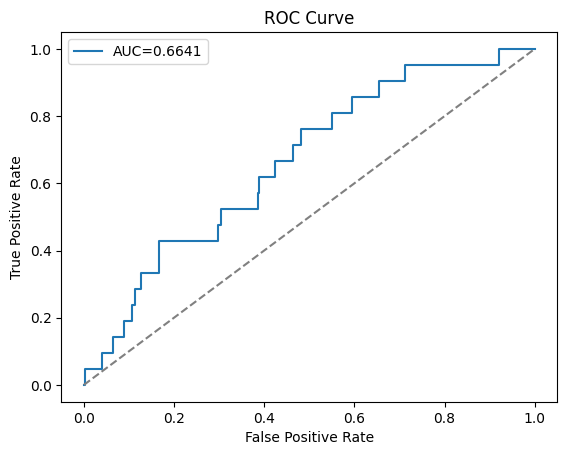

In [14]:
#roc curve code 
fpr,tpr,thresholds=roc_curve(y_test,y_pred_prob)
auc=roc_auc_score(y_test,y_pred_prob)
plt.plot(fpr,tpr,label=f"AUC={auc:.4f}")
plt.plot([0,1],[0,1],'--',color='gray')#ye dashed line random classifier ko represent karta hai
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [15]:
#false postive rate matlab ki kitne pass ko fail predict kiya gaya hai

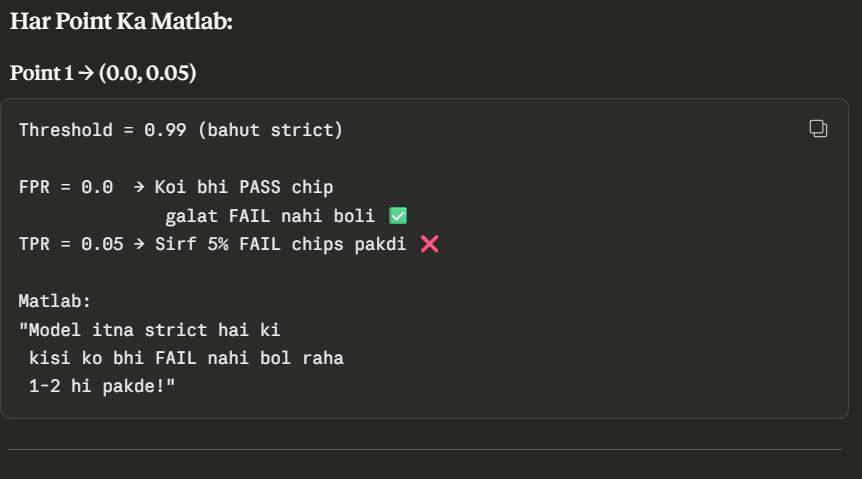

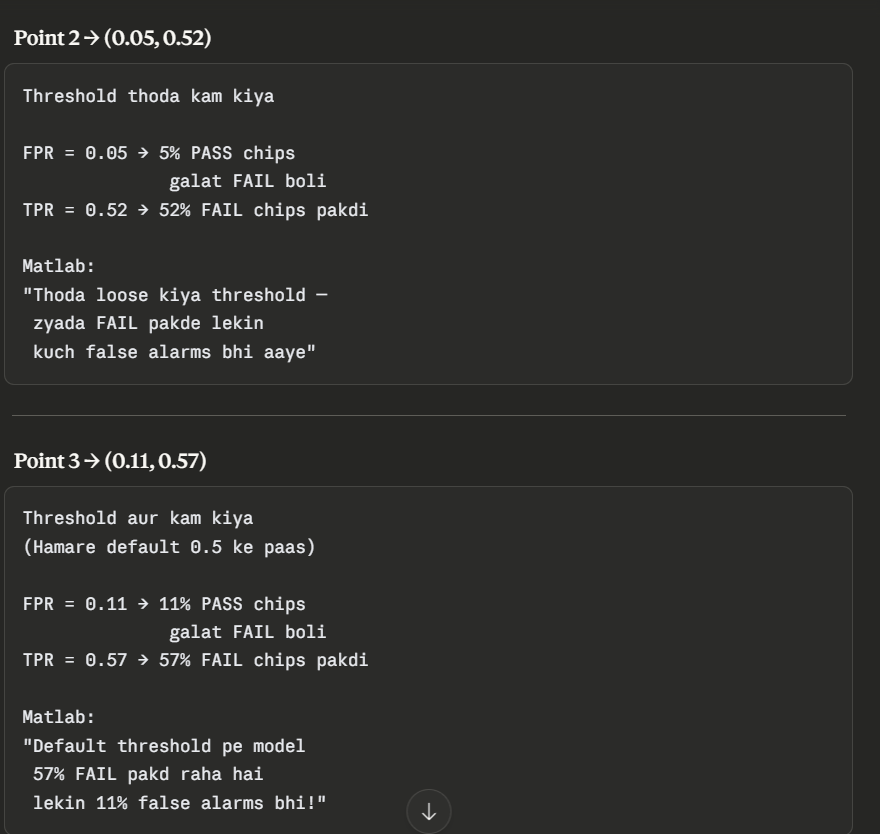

3 rd example se samjo 
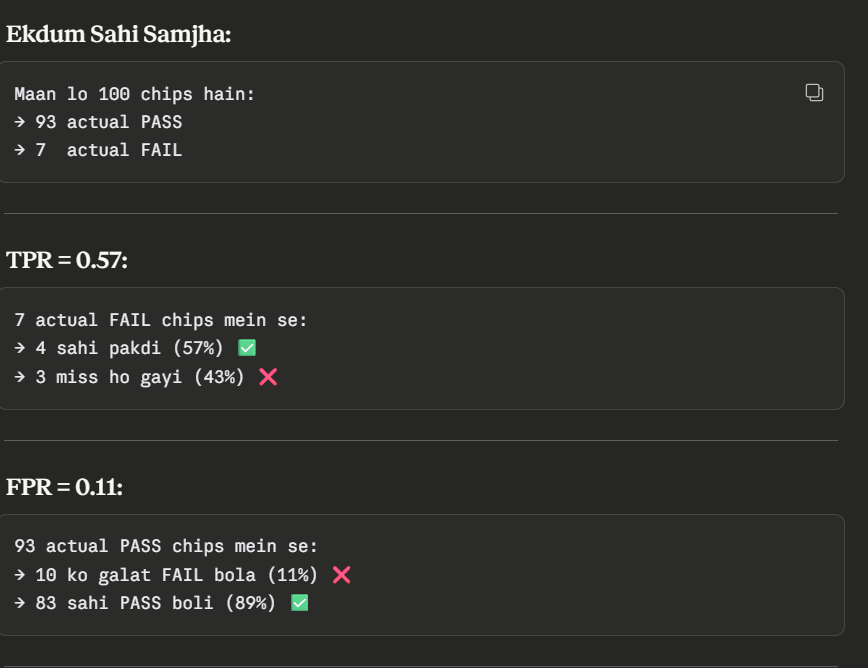

In [16]:
#ab hum optimal threshold nikalege wo hoga jaha f1 score maximum hoga kyki abhi default threshold pr model saare fail dhund nhi paara 

In [17]:
from sklearn.metrics import precision_recall_curve
precision,recall,thresholds=precision_recall_curve(y_test,y_pred_prob)
f1_scores=2*(precision[:-1]*recall[:-1])/(precision[:-1]+recall[:-1]+1e-10)#ye 1e-10 isliye add kiya taki zero division error na aaye


best_threshold=thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {best_threshold:.4f}")

#predict from optimal threshold 
y_pred_optimal = (y_pred_prob >= best_threshold).astype(int)

print("\nDefault (0.5):")
print(classification_report(y_test, y_pred,
      target_names=['PASS(0)', 'FAIL(1)']))

print(f"\nOptimal ({best_threshold:.3f}):")
print(classification_report(y_test, y_pred_optimal,
      target_names=['PASS(0)', 'FAIL(1)']))

Optimal Threshold: 0.3395

Default (0.5):
              precision    recall  f1-score   support

     PASS(0)       0.94      0.89      0.91       293
     FAIL(1)       0.13      0.24      0.17        21

    accuracy                           0.84       314
   macro avg       0.54      0.56      0.54       314
weighted avg       0.89      0.84      0.86       314


Optimal (0.339):
              precision    recall  f1-score   support

     PASS(0)       0.95      0.83      0.89       293
     FAIL(1)       0.16      0.43      0.23        21

    accuracy                           0.81       314
   macro avg       0.55      0.63      0.56       314
weighted avg       0.90      0.81      0.84       314



In [18]:
#random forest classifier

In [19]:
#sabse pehle decision tree thoda samjata hu 

#making cases based on certain consition to make up final decision 


""" Sensor_42 > 500?
├── Haan → Sensor_123 > 200?
│          ├── Haan → FAIL ❌
│          └── Nahi → PASS ✅
└── Nahi → Sensor_67 < 100?
           ├── Haan → FAIL ❌
           └── Nahi → PASS ✅ """

' Sensor_42 > 500?\n├── Haan → Sensor_123 > 200?\n│          ├── Haan → FAIL ❌\n│          └── Nahi → PASS ✅\n└── Nahi → Sensor_67 < 100?\n           ├── Haan → FAIL ❌\n           └── Nahi → PASS ✅ '

In [20]:
#disadvantage of decision tree is training data pr perfectly fit ho jata hai to usko overfitting kehte hai

#fail in new questions


In [21]:
#random forest taking decision from multiple decision trees and taking majority vote to make final decision

""" Step 1: 100 alag trees banao

Step 2: Har tree ke liye:
        → Random samples lo (bootstrap)
        → Random features lo
        → Tree train karo

Step 3: Prediction karte waqt:
        → Sab trees vote karein
        → Majority wins!

PASS votes = 60
FAIL votes = 40
→ Final: PASS ✅ """



#bagging hota agr kisi bhi group ko bnate waqt random sampling karte hai to usko bagging kehte hai



""" Logistic Regression:
→ Linear boundary banata hai
→ Complex patterns miss karta hai

Random Forest:
→ Non-linear boundaries
→ Feature interactions seekhta hai
→ Outliers se robust
→ Feature importance deta hai!  """

' Logistic Regression:\n→ Linear boundary banata hai\n→ Complex patterns miss karta hai\n\nRandom Forest:\n→ Non-linear boundaries\n→ Feature interactions seekhta hai\n→ Outliers se robust\n→ Feature importance deta hai!  '

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=200,
      #200 trees
      max_depth=10, min_samples_leaf=5,max_features='sqrt',random_state=42,class_weight='balanced',n_jobs=-1 
)


rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)
y_pred_rf_prob=rf.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_rf,
      target_names=['PASS(0)', 'FAIL(1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_rf_prob):.4f}")

              precision    recall  f1-score   support

     PASS(0)       0.93      0.99      0.96       293
     FAIL(1)       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314

ROC-AUC: 0.7886


In [23]:
# Optimal threshold dhundo
precisions_rf, recalls_rf, thresholds_rf = \
    precision_recall_curve(y_test, y_pred_rf_prob)

f1_scores_rf = 2 * (precisions_rf[:-1] * recalls_rf[:-1]) / \
               (precisions_rf[:-1] + recalls_rf[:-1] + 1e-8)

best_threshold_rf = thresholds_rf[np.argmax(f1_scores_rf)]
print(f"Optimal Threshold: {best_threshold_rf:.3f}")

y_pred_rf_optimal = (y_pred_rf_prob >= best_threshold_rf).astype(int)

print(classification_report(y_test, y_pred_rf_optimal,
      target_names=['PASS(0)', 'FAIL(1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_rf_prob):.4f}")

Optimal Threshold: 0.343
              precision    recall  f1-score   support

     PASS(0)       0.96      0.90      0.93       293
     FAIL(1)       0.23      0.43      0.30        21

    accuracy                           0.87       314
   macro avg       0.59      0.66      0.61       314
weighted avg       0.91      0.87      0.88       314

ROC-AUC: 0.7886


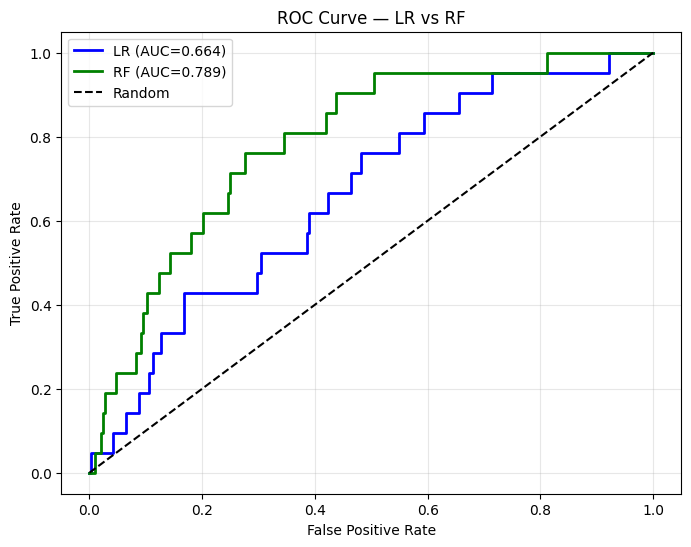

In [24]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_prob)
auc_rf = roc_auc_score(y_test, y_pred_rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue',
         linewidth=2,
         label=f'LR (AUC={auc:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green',
         linewidth=2,
         label=f'RF (AUC={auc_rf:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — LR vs RF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
# Feature names lo
feature_names = pd.read_csv(
    '../data/processed/secom_features.csv').columns[:-1].tolist()

# Importance dataframe
importance_df = pd.DataFrame({
    'feature'   : feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 5 Sensors:")
print(importance_df.head())

Top 5 Sensors:
        feature  importance
39    sensor_59    0.042057
157  sensor_486    0.041774
130  sensor_419    0.030901
22    sensor_33    0.028324
169  sensor_519    0.025380


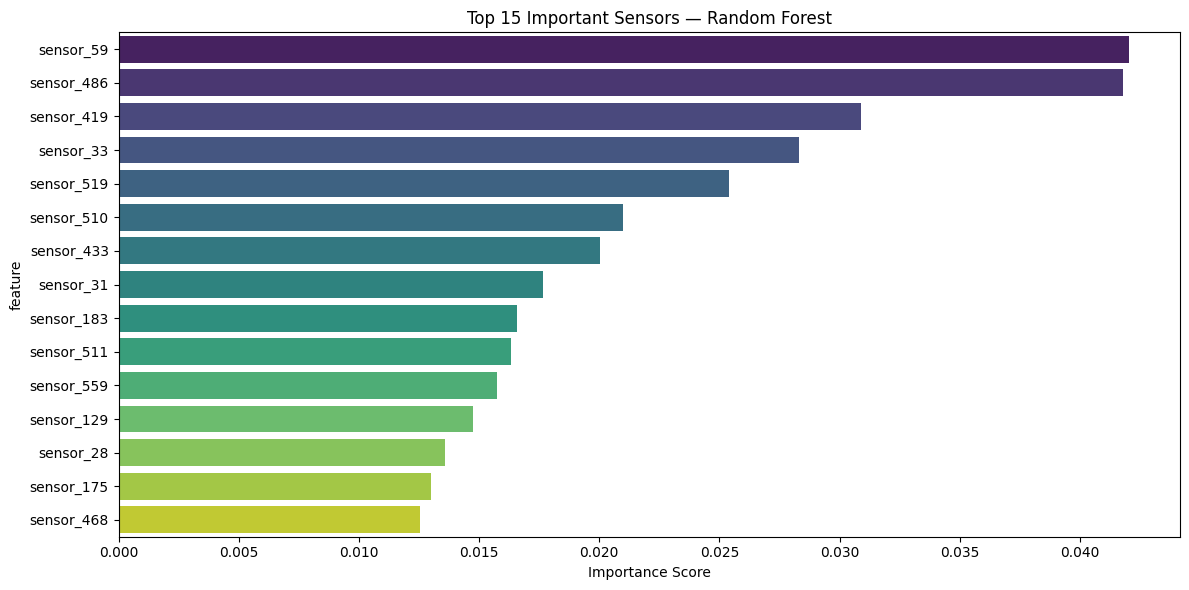

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df.head(15),
            x='importance', y='feature',
            palette='viridis')
plt.title('Top 15 Important Sensors — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()

plt.show()

In [27]:
#this shows sensor 59,486,419 contribute more in failure rate

In [28]:
#normal hum krte hai gradient boosting xg boost special hota hai kyoki 

""" Normal Gradient Boosting se better:

1. Regularization built-in
   → Overfitting kam hota hai

2. Parallel processing
   → Fast training

3. Missing values handle karta hai
   → Automatically!

4. Pruning karta hai
   → Useless branches hatata hai

5. Cache optimization
   → Memory efficient """

' Normal Gradient Boosting se better:\n\n1. Regularization built-in\n   → Overfitting kam hota hai\n\n2. Parallel processing\n   → Fast training\n\n3. Missing values handle karta hai\n   → Automatically!\n\n4. Pruning karta hai\n   → Useless branches hatata hai\n\n5. Cache optimization\n   → Memory efficient '

In [29]:
from xgboost import XGBClassifier
#dekho ji hamne class_weight balanced kra tha rf mei u
#uska alterntaive hi hai ye ek tarah se but smote ke baad sclae 1 hai 

scale=(y_train==0).sum()/(y_train==1).sum() #calculate weight of fail samples

xgb=XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metrics='logloss'
)

xgb.fit(X_train,y_train)

y_pred_xgb=xgb.predict(X_test)
y_proba_xgb=xgb.predict_proba(X_test)[:,1]

precisions_xgb, recalls_xgb, thresholds_xgb = \
    precision_recall_curve(y_test, y_proba_xgb)


f1_scores_xgb = 2 * (precisions_xgb[:-1] * recalls_xgb[:-1]) / \
                (precisions_xgb[:-1] + recalls_xgb[:-1] + 1e-8)


best_threshold_xgb = thresholds_xgb[np.argmax(f1_scores_xgb)]
print(f"Optimal Threshold: {best_threshold_xgb:.3f}")
y_pred_xgb_optimal = (y_proba_xgb >= best_threshold_xgb).astype(int)

print(classification_report(y_test, y_pred_xgb_optimal,
      target_names=['PASS(0)', 'FAIL(1)']))

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")



Optimal Threshold: 0.047
              precision    recall  f1-score   support

     PASS(0)       0.96      0.89      0.93       293
     FAIL(1)       0.26      0.52      0.35        21

    accuracy                           0.87       314
   macro avg       0.61      0.71      0.64       314
weighted avg       0.92      0.87      0.89       314

ROC-AUC: 0.7598


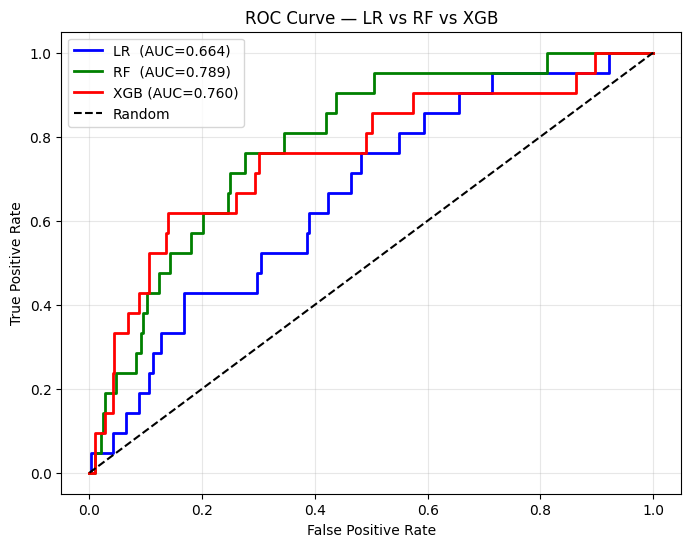

In [31]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue',
         linewidth=2, label=f'LR  (AUC={auc:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green',
         linewidth=2, label=f'RF  (AUC={auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='red',
         linewidth=2, label=f'XGB (AUC={auc_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — LR vs RF vs XGB')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [32]:
#cross validation isliye kyoki abhi hamne 80% data trining ke liye use kra 20% testing socho ab wo 20% test data lucky tha 


""" Poora data 5 parts mein baanto:

Fold 1: [TEST] [train] [train] [train] [train]
Fold 2: [train] [TEST] [train] [train] [train]
Fold 3: [train] [train] [TEST] [train] [train]
Fold 4: [train] [train] [train] [TEST] [train]
Fold 5: [train] [train] [train] [train] [TEST]

Har fold pe model train + evaluate karo
5 scores ka average lo → Final score! """

' Poora data 5 parts mein baanto:\n\nFold 1: [TEST] [train] [train] [train] [train]\nFold 2: [train] [TEST] [train] [train] [train]\nFold 3: [train] [train] [TEST] [train] [train]\nFold 4: [train] [train] [train] [TEST] [train]\nFold 5: [train] [train] [train] [train] [TEST]\n\nHar fold pe model train + evaluate karo\n5 scores ka average lo → Final score! '

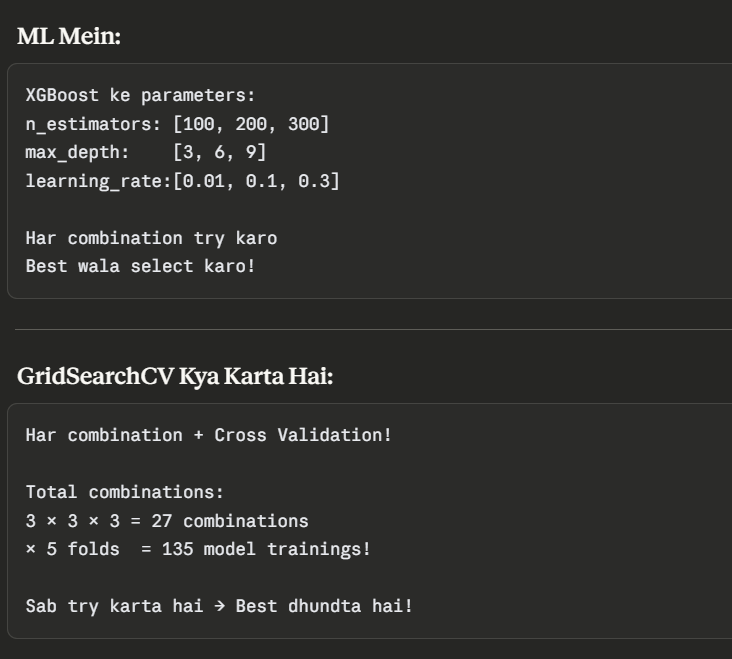

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score,GridSearchCV

# Stratified KFold — class ratio maintain karo
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost ka CV score
cv_scores = cross_val_score(
    xgb, X_train, y_train,
    cv=cv,
    scoring='roc_auc'
)



In [34]:
# Parameter grid
param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 6],
    'learning_rate' : [0.05, 0.1],
}

# GridSearch
grid_search = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f" Best Params: {grid_search.best_params_}")
print(f" Best AUC   : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
 Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
 Best AUC   : 0.9989


In [35]:
# Best model
best_xgb = grid_search.best_estimator_

# Predictions
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

# Threshold tuning
p, r, t = precision_recall_curve(y_test, y_proba_best)
f1 = 2 * (p[:-1] * r[:-1]) / (p[:-1] + r[:-1] + 1e-8)
best_t = t[np.argmax(f1)]

y_pred_best = (y_proba_best >= best_t).astype(int)

print(f"Best Threshold: {best_t:.3f}")
print(f"\n{classification_report(y_test, y_pred_best, target_names=['PASS(0)', 'FAIL(1)'])}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

Best Threshold: 0.080

              precision    recall  f1-score   support

     PASS(0)       0.97      0.87      0.92       293
     FAIL(1)       0.24      0.57      0.34        21

    accuracy                           0.85       314
   macro avg       0.61      0.72      0.63       314
weighted avg       0.92      0.85      0.88       314

ROC-AUC: 0.7422


In [36]:
print("=" * 55)
print("   FINAL MODEL COMPARISON")
print("=" * 55)
print(f"{'Model':<20} {'AUC':>8} {'FAIL-R':>8} {'FAIL-F1':>8}")
print("-" * 55)
print(f"{'LR':<20} {'0.664':>8} {'0.43':>8} {'0.23':>8}")
print(f"{'RF':<20} {'0.789':>8} {'0.43':>8} {'0.30':>8}")
print(f"{'XGB (default)':<20} {'0.760':>8} {'0.52':>8} {'0.35':>8}")
print(f"{'XGB (tuned)':<20} {roc_auc_score(y_test, y_proba_best):>8.3f} {'???':>8} {'???':>8}")
print("=" * 55)

   FINAL MODEL COMPARISON
Model                     AUC   FAIL-R  FAIL-F1
-------------------------------------------------------
LR                      0.664     0.43     0.23
RF                      0.789     0.43     0.30
XGB (default)           0.760     0.52     0.35
XGB (tuned)             0.742      ???      ???


In [37]:
print(classification_report(y_test, y_pred_best,
      target_names=['PASS(0)', 'FAIL(1)']))

              precision    recall  f1-score   support

     PASS(0)       0.97      0.87      0.92       293
     FAIL(1)       0.24      0.57      0.34        21

    accuracy                           0.85       314
   macro avg       0.61      0.72      0.63       314
weighted avg       0.92      0.85      0.88       314



In [38]:
""" Overall AUC    → RF       (0.789) 
FAIL Recall    → XGB Tuned(0.57)  
FAIL F1        → XGB Default(0.35) """

' Overall AUC    → RF       (0.789) \nFAIL Recall    → XGB Tuned(0.57)  \nFAIL F1        → XGB Default(0.35) '

In [39]:
""" XGB Tuned best hai! 

Kyunki:
FAIL Recall = 0.57
21 mein se 12 FAIL pakde!

Pehle LR mein sirf 5 pakde the
Ab 12 pakad rahe hain! """

' XGB Tuned best hai! \n\nKyunki:\nFAIL Recall = 0.57\n21 mein se 12 FAIL pakde!\n\nPehle LR mein sirf 5 pakde the\nAb 12 pakad rahe hain! '